In [9]:
!pip install kaggle -q

from google.colab import files
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Dataset'i indir
!kaggle datasets download -d bhushandivekar/video-game-sales-and-industry-data-1980-2024
!kaggle datasets download -d thedevastator/video-game-sales-and-ratings
!kaggle datasets download -d anandshaw2001/video-game-sales

#zip dosyaları aç
import zipfile

zip_files = [
    "video-game-sales-and-industry-data-1980-2024.zip",
    "video-game-sales-and-ratings.zip",
    "video-game-sales.zip"
]

for zip_name in zip_files:
    folder_name = zip_name.replace(".zip", "")
    os.makedirs(folder_name, exist_ok=True)
    with zipfile.ZipFile(zip_name, 'r') as zip_ref:
        zip_ref.extractall(folder_name)

print("Zip dosyalari acildi.")

#hangi dosyalar geldi
print("Klasor icerigi:")
for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

#datasetleri oku
import pandas as pd

df1 = pd.read_csv("video-game-sales/vgsales.csv")
df2 = pd.read_csv("video-game-sales-and-ratings/Video_Games.csv")
df3 = pd.read_csv("video-game-sales-and-industry-data-1980-2024/Video Games Sales (1980-2024) - Raw.csv")

print("df1:", df1.shape)
print("df2:", df2.shape)
print("df3:", df3.shape)

df1.head()

#sütun adlarını oku
print(df1.columns)
print(df2.columns)
print(df3.columns)

#dataset1 userscore ve criticscore yok
df1 = df1.rename(columns={
    'Name': 'name',
    'Platform': 'platform',
    'Year': 'year',
    'Genre': 'genre',
    'Publisher': 'publisher',
    'Global_Sales': 'global_sales',
    'JP_Sales':'jp_sales',
    'NA_Sales':'na_sales',
    'EU_Sales':'eu_sales'
})

df1['critic_score'] = pd.NA
df1['user_score'] = pd.NA

df1 = df1[['name','platform','year','genre','publisher','global_sales','jp_sales','critic_score','user_score','na_sales','eu_sales']]

#dataset2, tam veri
df2 = df2.rename(columns={
    'Name': 'name',
    'Platform': 'platform',
    'Year_of_Release': 'year',
    'Genre': 'genre',
    'Publisher': 'publisher',
    'Global_Sales': 'global_sales',
    'JP_Sales':'jp_sales',
    'NA_Sales':'na_sales',
    'EU_Sales':'eu_sales',
    'Critic_Score': 'critic_score',
    'User_Score': 'user_score'
})

df2 = df2[['name','platform','year','genre','publisher','global_sales','jp_sales','na_sales','eu_sales','critic_score','user_score']]

#dataset3 userscore yok
df3 = df3.rename(columns={
    'title': 'name',
    'console': 'platform',
    'release_date': 'year',
    'genre': 'genre',
    'publisher': 'publisher',
    'total_sales': 'global_sales',
    'jp_sales':'jp_sales',
    'na_sales':'na_sales',
    'critic_score': 'critic_score'
})

df3['eu_sales'] = pd.NA
df3['user_score'] = pd.NA


df3 = df3[['name','platform','year','genre','publisher','global_sales','jp_sales','na_sales','critic_score','eu_sales','user_score']]





Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/bhushandivekar/video-game-sales-and-industry-data-1980-2024
License(s): CC0-1.0
video-game-sales-and-industry-data-1980-2024.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/thedevastator/video-game-sales-and-ratings
License(s): other
video-game-sales-and-ratings.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/anandshaw2001/video-game-sales
License(s): CC0-1.0
video-game-sales.zip: Skipping, found more recently modified local copy (use --force to force download)
Zip dosyalari acildi.
Klasor icerigi:
./video-game-sales-and-industry-data-1980-2024.zip
./video-game-sales.zip
./video-game-sales-and-ratings.zip
./.config/.last_opt_in_prompt.yaml
./.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
./.config/default_configs.db
./.

In [10]:

final_df = pd.concat([df1, df2, df3], ignore_index=True)

/tmp/ipykernel_52461/705220216.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  final_df = pd.concat([df1, df2, df3], ignore_index=True)


In [11]:

dup_rows = final_df[
    final_df.duplicated(
        subset=['name','platform','year','genre','publisher','global_sales','jp_sales','critic_score','user_score'],
        keep=False
    )
]

dup_rows


,name,platform,year,genre,publisher,global_sales,jp_sales,critic_score,user_score,na_sales,eu_sales
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24,6.81,NaN,NaN,29.08,3.58
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37,10.22,NaN,NaN,11.27,8.89
5,Tetris,GB,1989.0,Puzzle,Nintendo,30.26,4.22,NaN,NaN,23.20,2.26
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,28.31,0.28,NaN,NaN,26.93,0.63
12,Pokemon Gold/Pokemon Silver,GB,1999.0,Role-Playing,Nintendo,23.10,7.20,NaN,NaN,9.00,6.18
...,...,...,...,...,...,...,...,...,...,...,...
93692,The Aquatic Games starring James Pond and the ...,GEN,01-01-1993,Sports,Electronic Arts,NaN,NaN,NaN,NaN,NaN,NaN
94698,Z,PC,31-07-1996,Strategy,Virgin Interactive,NaN,NaN,NaN,NaN,NaN,NaN
94937,Battlezone II: Combat Commander,PC,31-12-1999,Strategy,Activision,NaN,NaN,NaN,NaN,NaN,NaN
94938,Battlezone II: Combat Commander,PC,31-12-1999,Strategy,Activision,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
final_df['year'] = pd.to_datetime(final_df['year'], errors='coerce', dayfirst=True).dt.year

In [14]:
print(final_df[['year']].sample(20))

         year
31941  1970.0
34313  2013.0
22928  1970.0
75380  2005.0
85800  2010.0
94277  2020.0
23028  1970.0
41941  2002.0
41264  2012.0
87232  1995.0
92117  2007.0
54143  2007.0
81259  2016.0
79991  2003.0
40945  2007.0
43080  1998.0
58630  2006.0
28293  1970.0
51048  2018.0
35344  2008.0


In [42]:
import numpy as np
import pandas as pd


# 2. KARMAŞAYI ÇÖZEN KISIM:
# Sütunlarda string olarak yazılmış 'None', 'null' veya manuel eklediğin None'ları
# gerçek np.nan (Not a Number) formatına çekiyoruz.
bosluk_varyasyonlari = ['None', 'none', 'null', 'NULL', 'nan', 'NaN', ' ', 'N/A']
final_df.replace(bosluk_varyasyonlari, np.nan, inplace=True)
# Veri setinden rastgele 20 örnek çeker
final_df.sample(20)

,name,platform,year,genre,publisher,global_sales,jp_sales,critic_score,user_score,na_sales,eu_sales
20300,Tiger Woods PGA Tour 13,PS3,1970.0,Sports,Electronic Arts,0.54,0.00,75.0,5.7,0.24,0.21
21087,DanceStar Party,PS3,1970.0,Misc,Sony Computer Entertainment,0.43,0.00,NaN,NaN,0.00,0.34
48102,Pro Evolution Soccer 2017,PC,2016.0,Sports,Konami Digital Entertainment,0.03,NaN,NaN,NaN,NaN,NaN
13076,Tabi no Yubisashi Kaiwachou DS: DS Series 2 Ch...,DS,1970.0,Misc,Nintendo,0.05,0.05,NaN,NaN,0.00,0.00
11768,Boxing,PS,1970.0,Fighting,Midas Interactive Entertainment,0.07,0.00,NaN,NaN,0.04,0.03
6807,Marvel vs. Capcom Origins,PS2,1970.0,Fighting,Capcom,0.24,0.02,NaN,NaN,0.11,0.08
25836,Battlefield: Hardline,PC,1970.0,Shooter,Electronic Arts,0.14,0.00,71.0,3.8,0.00,0.13
2347,Call of Duty: Modern Warfare 2,PC,1970.0,Shooter,Activision,0.89,0.00,NaN,NaN,0.01,0.79
20653,Medal of Honor,PC,1970.0,Shooter,Electronic Arts,0.49,0.00,72.0,6.4,0.20,0.23
32448,Hurry Up Hedgehog!,DS,1970.0,Racing,O-Games,0.02,0.00,NaN,NaN,0.02,0.00


In [44]:
final_df = final_df.dropna(subset=['global_sales'])

In [68]:
final_df.loc[final_df['year'] == 1970, 'year'] = np.nan
final_df = final_df.dropna(subset=['year'])

In [69]:
final_df.shape

(18832, 11)

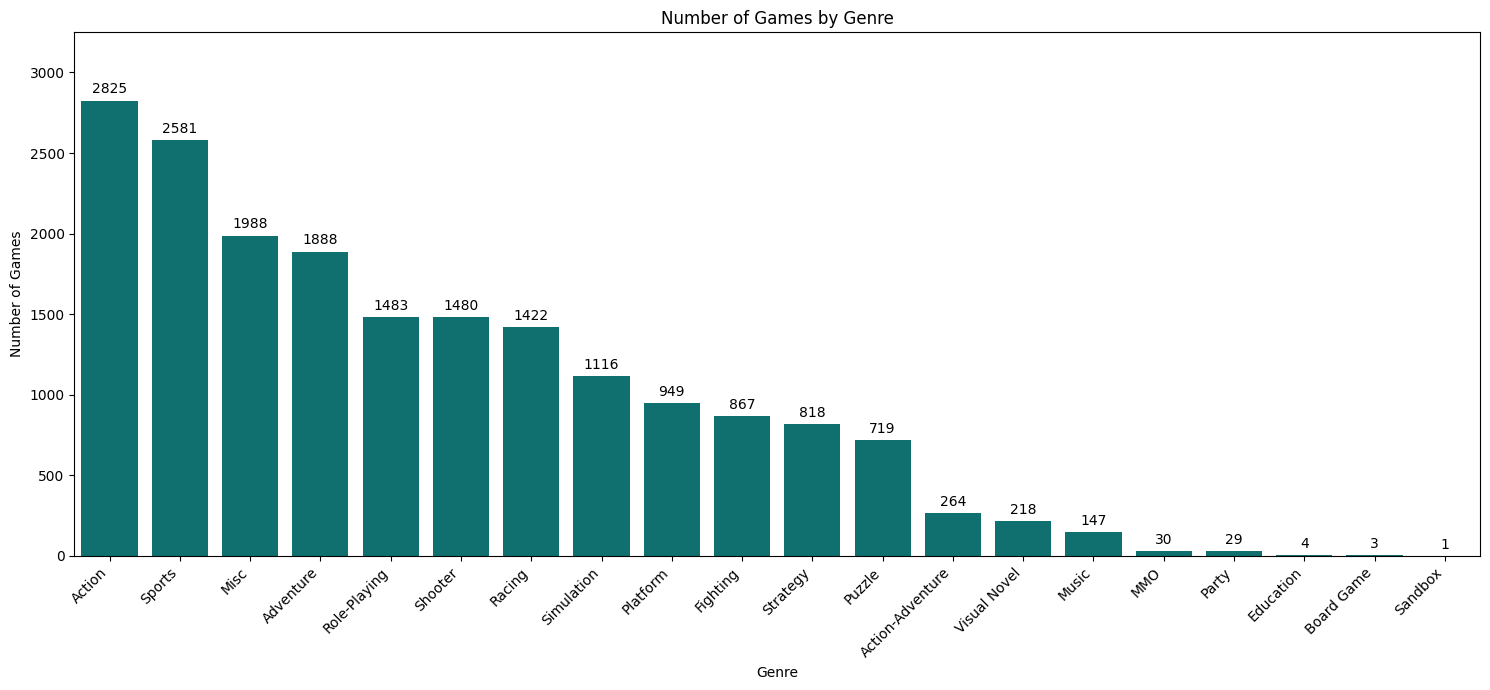

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = final_df['genre'].value_counts().reset_index()
genre_counts.columns = ['genre', 'count']

# Azalan sıraya göre sıralama
genre_counts = genre_counts.sort_values(by='count', ascending=False)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=genre_counts,
    x='genre',
    y='count',
    color='teal'
)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, genre_counts['count'].max() * 1.15)

plt.xticks(rotation=45, ha='right')
plt.title("Number of Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")

plt.tight_layout()
plt.show()

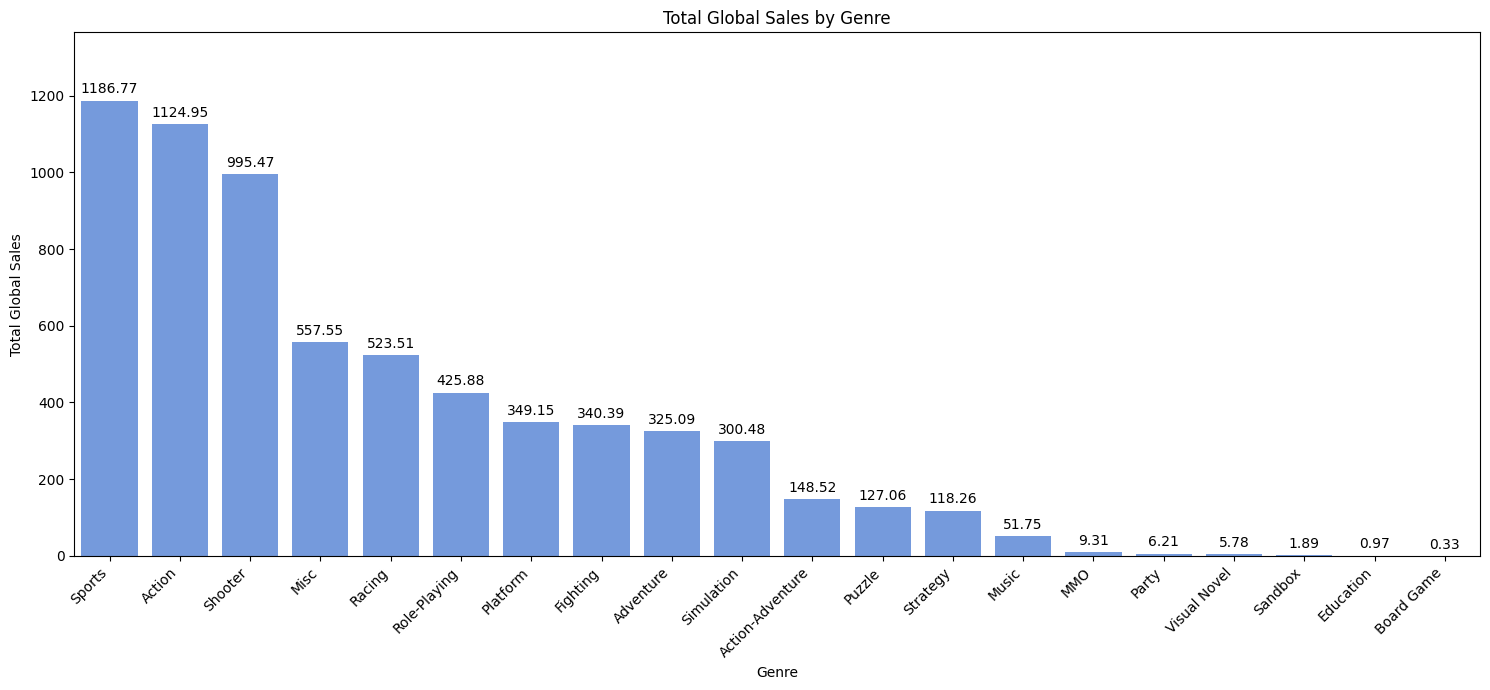

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_sales = final_df.groupby('genre')['global_sales'].sum().reset_index()
genre_sales = genre_sales.sort_values(by='global_sales', ascending=False)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=genre_sales,
    x='genre',
    y='global_sales',
    color='cornflowerblue'
)

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.ylim(0, genre_sales['global_sales'].max() * 1.15)

plt.xticks(rotation=45, ha='right')
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Total Global Sales")

plt.tight_layout()
plt.show()

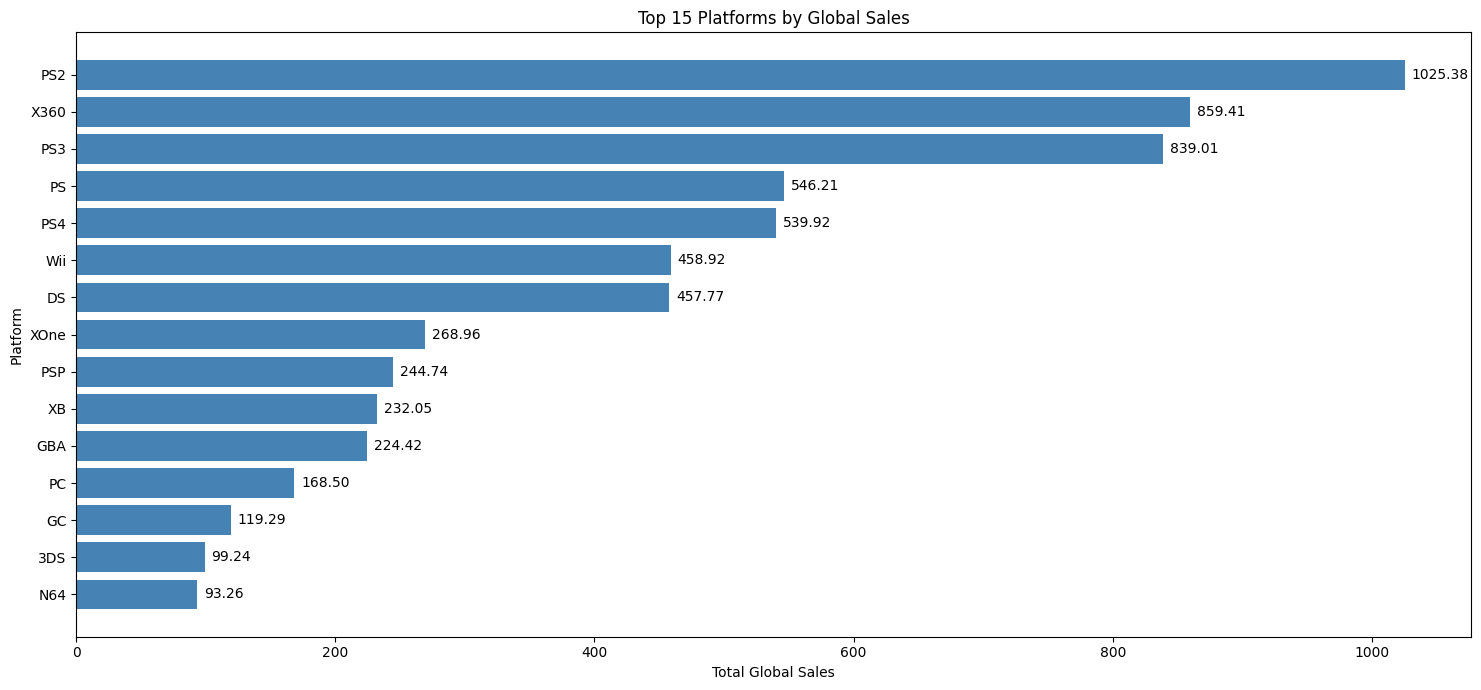

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# global_sales sayısal olsun
final_df['global_sales'] = pd.to_numeric(final_df['global_sales'], errors='coerce')

# Platformlara göre toplam satış
platform_sales = (
    final_df
    .dropna(subset=['platform', 'global_sales'])
    .groupby('platform', as_index=False)['global_sales']
    .sum()
    .sort_values(by='global_sales', ascending=False)
)

# İlk 15 platformu alalım
top_platform_sales = platform_sales.head(15)

plt.figure(figsize=(15, 7))

bars = plt.barh(
    top_platform_sales['platform'],
    top_platform_sales['global_sales'],
    color='steelblue'
)

# En yüksek değer üstte görünsün
plt.gca().invert_yaxis()

# Çubukların sonuna değer yazdırma
plt.bar_label(bars, fmt='%.2f', padding=5)

plt.title("Top 15 Platforms by Global Sales")
plt.xlabel("Total Global Sales")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()

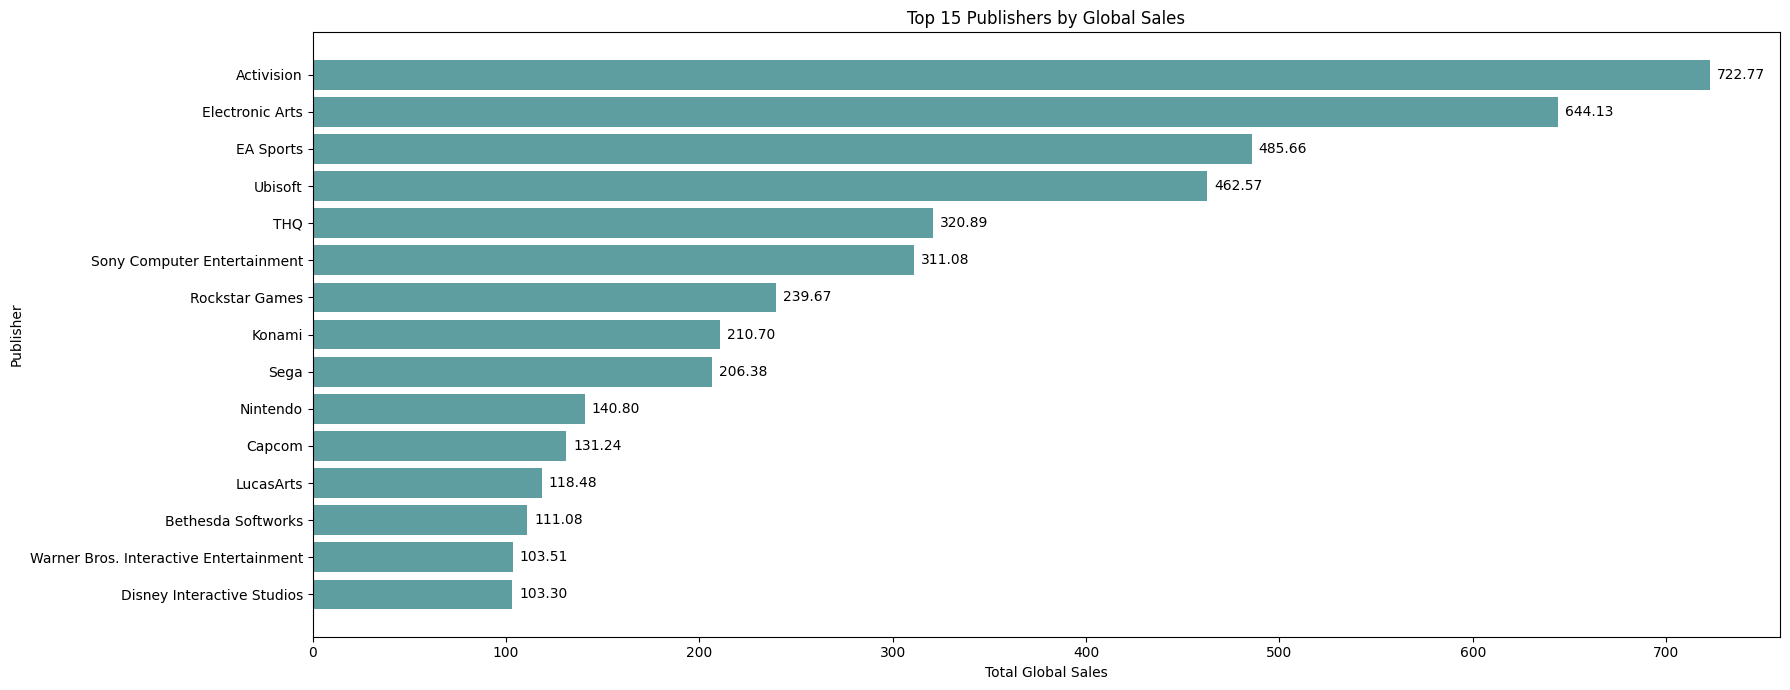

In [73]:
import matplotlib.pyplot as plt

publisher_sales = final_df.groupby('publisher')['global_sales'].sum().reset_index()
publisher_sales = publisher_sales.sort_values(by='global_sales', ascending=False).head(15)

plt.figure(figsize=(18, 7))

bars = plt.barh(
    publisher_sales['publisher'],
    publisher_sales['global_sales'],
    color='cadetblue'
)

plt.gca().invert_yaxis()

plt.bar_label(bars, fmt='%.2f', padding=5)

plt.title("Top 15 Publishers by Global Sales")
plt.xlabel("Total Global Sales")
plt.ylabel("Publisher")

plt.tight_layout()
plt.show()

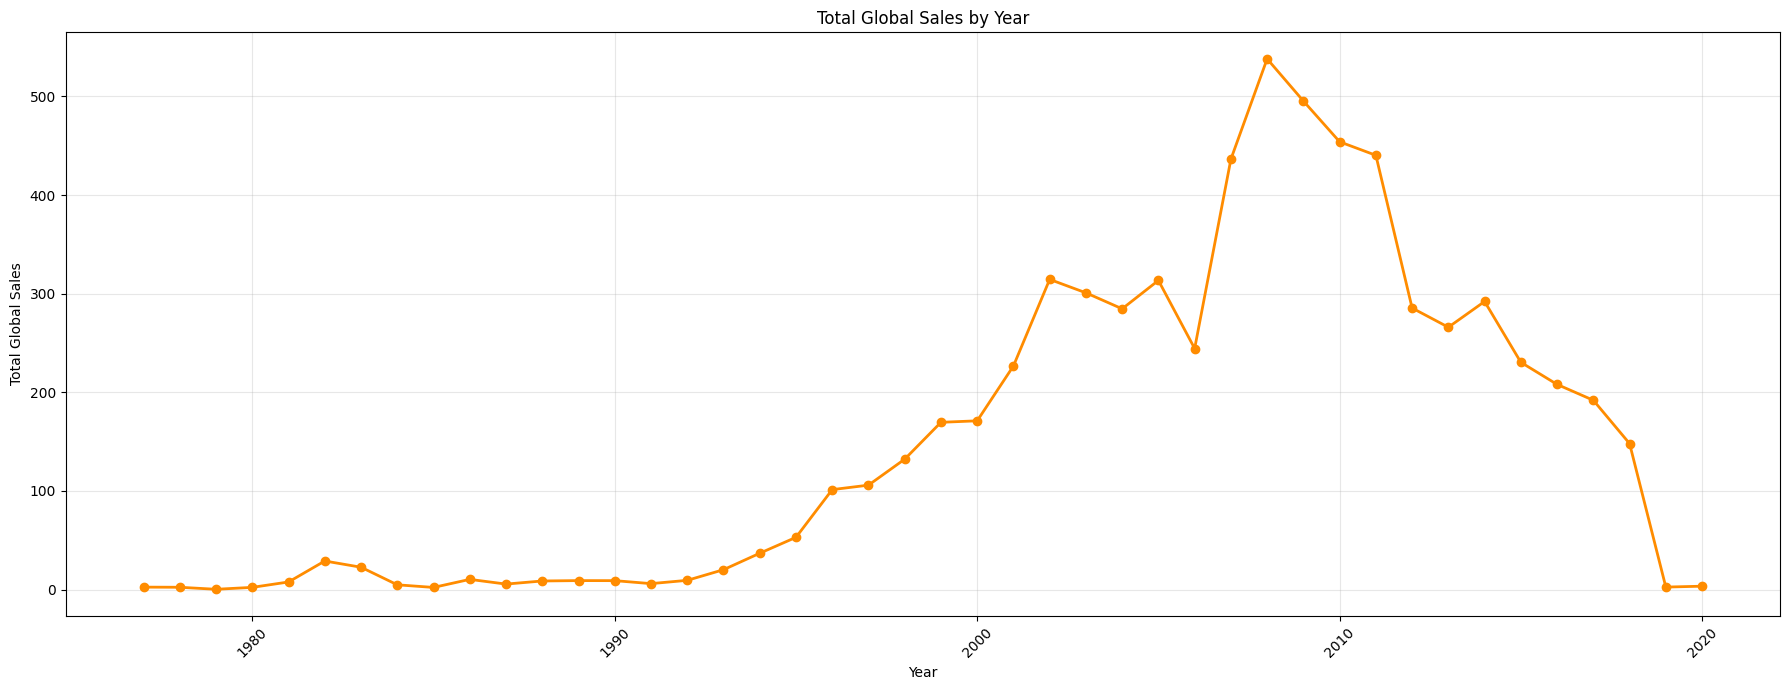

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

final_df['year'] = pd.to_numeric(final_df['year'], errors='coerce')

year_sales = final_df.groupby('year')['global_sales'].sum().reset_index()
year_sales = year_sales.dropna()
year_sales = year_sales.sort_values(by='year')

plt.figure(figsize=(18, 7))

plt.plot(
    year_sales['year'],
    year_sales['global_sales'],
    marker='o',
    linewidth=2,
    color='darkorange'
)

plt.title("Total Global Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Global Sales")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

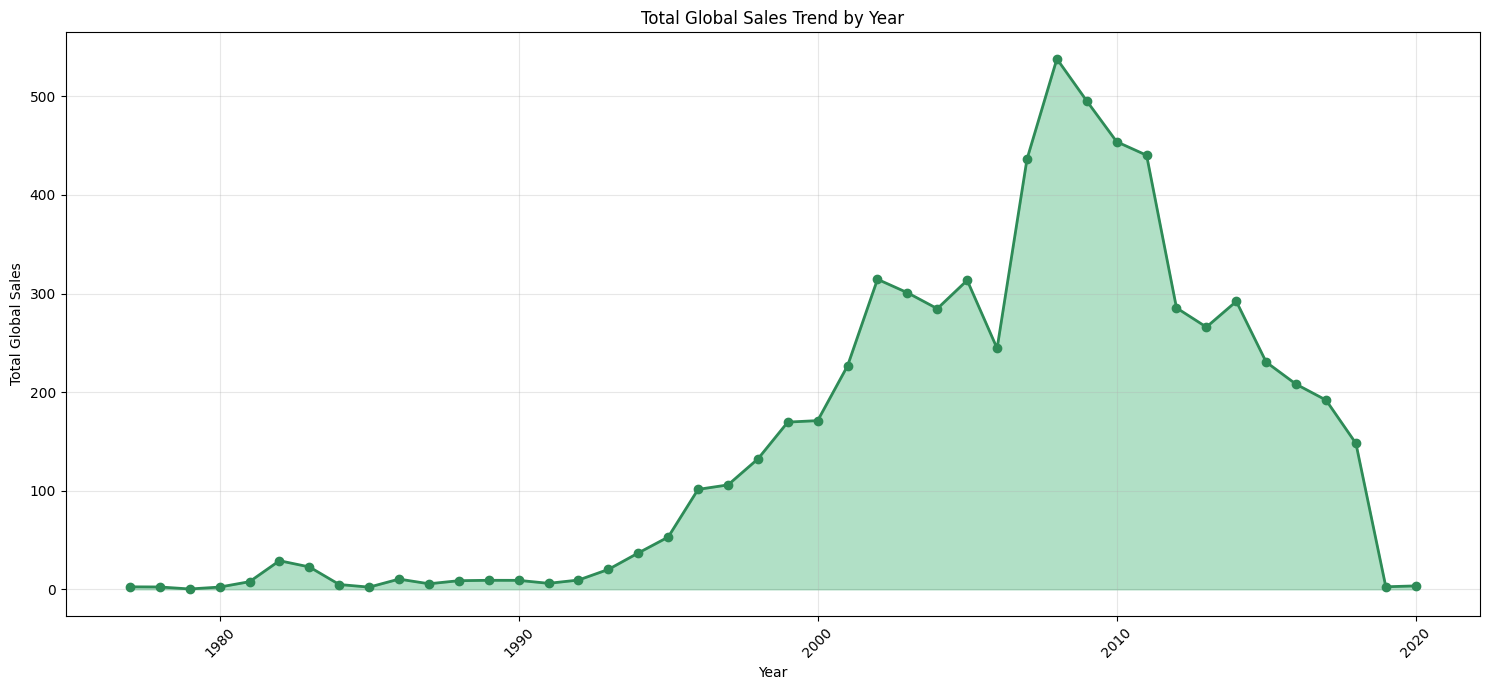

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

final_df['year'] = pd.to_numeric(final_df['year'], errors='coerce')

year_sales = final_df.groupby('year')['global_sales'].sum().reset_index()
year_sales = year_sales.dropna()
year_sales = year_sales.sort_values(by='year')

plt.figure(figsize=(15, 7))

plt.fill_between(
    year_sales['year'],
    year_sales['global_sales'],
    alpha=0.4,
    color='mediumseagreen'
)

plt.plot(
    year_sales['year'],
    year_sales['global_sales'],
    marker='o',
    linewidth=2,
    color='seagreen'
)

plt.title("Total Global Sales Trend by Year")
plt.xlabel("Year")
plt.ylabel("Total Global Sales")

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

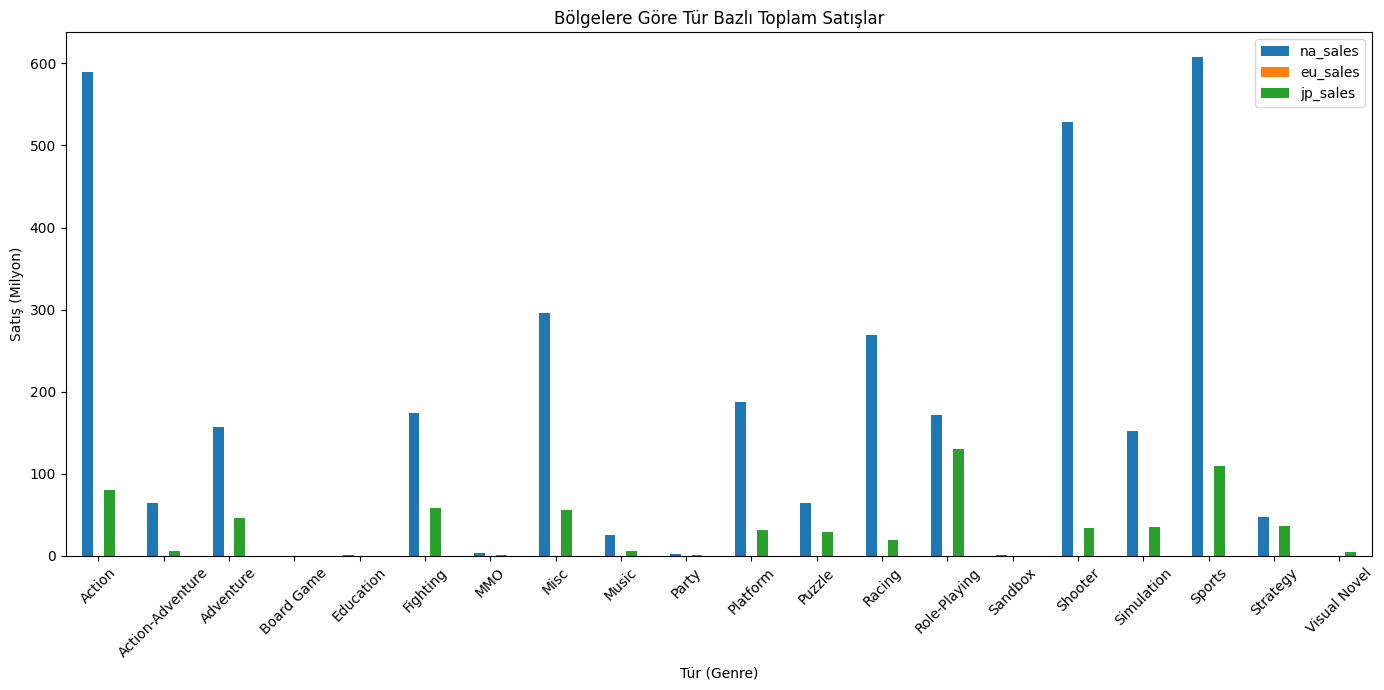

In [79]:
import matplotlib.pyplot as plt

# Genre bazlı toplam satışlar
genre_sales = final_df.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Grafik
genre_sales.plot(kind='bar', figsize=(14,7))
plt.title("Bölgelere Göre Tür Bazlı Toplam Satışlar")
plt.xlabel("Tür (Genre)")
plt.ylabel("Satış (Milyon)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

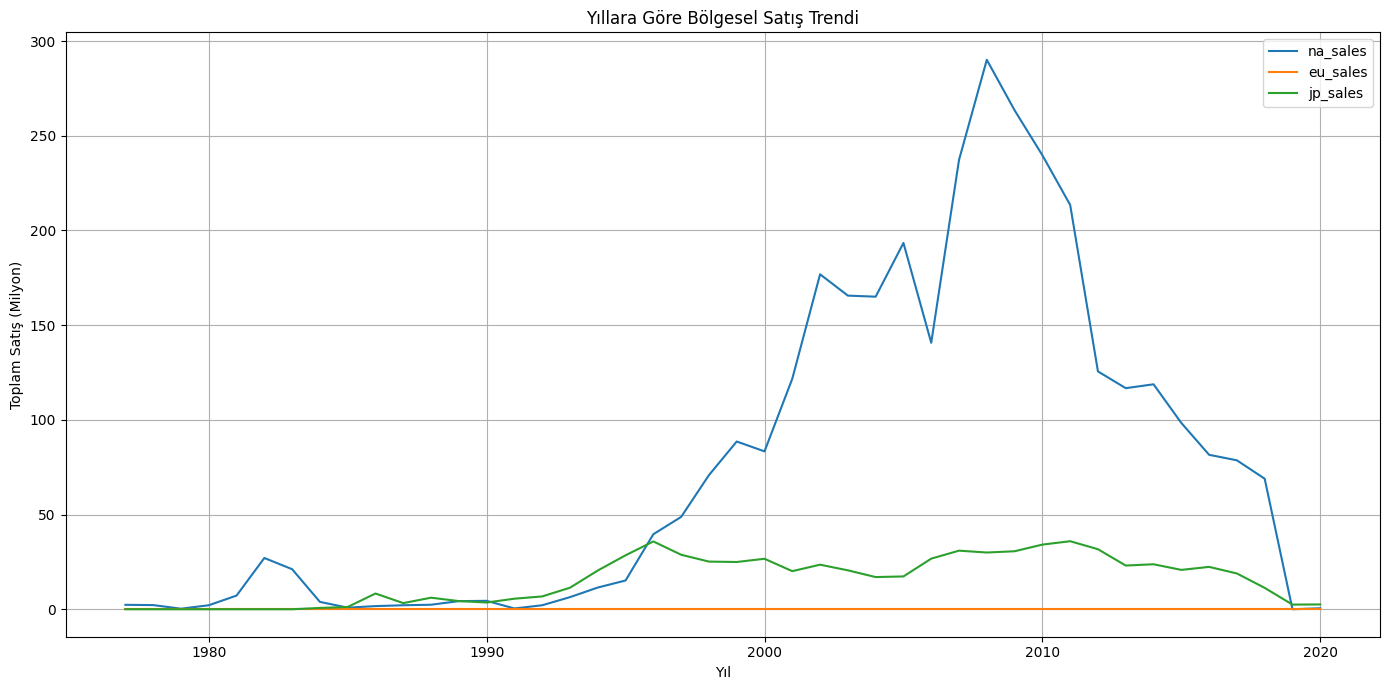

In [80]:
# Yıl bazlı toplam satış
yearly_sales = final_df.groupby('year')[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Grafik
yearly_sales.plot(figsize=(14,7))
plt.title("Yıllara Göre Bölgesel Satış Trendi")
plt.xlabel("Yıl")
plt.ylabel("Toplam Satış (Milyon)")
plt.grid(True)
plt.tight_layout()
plt.show()

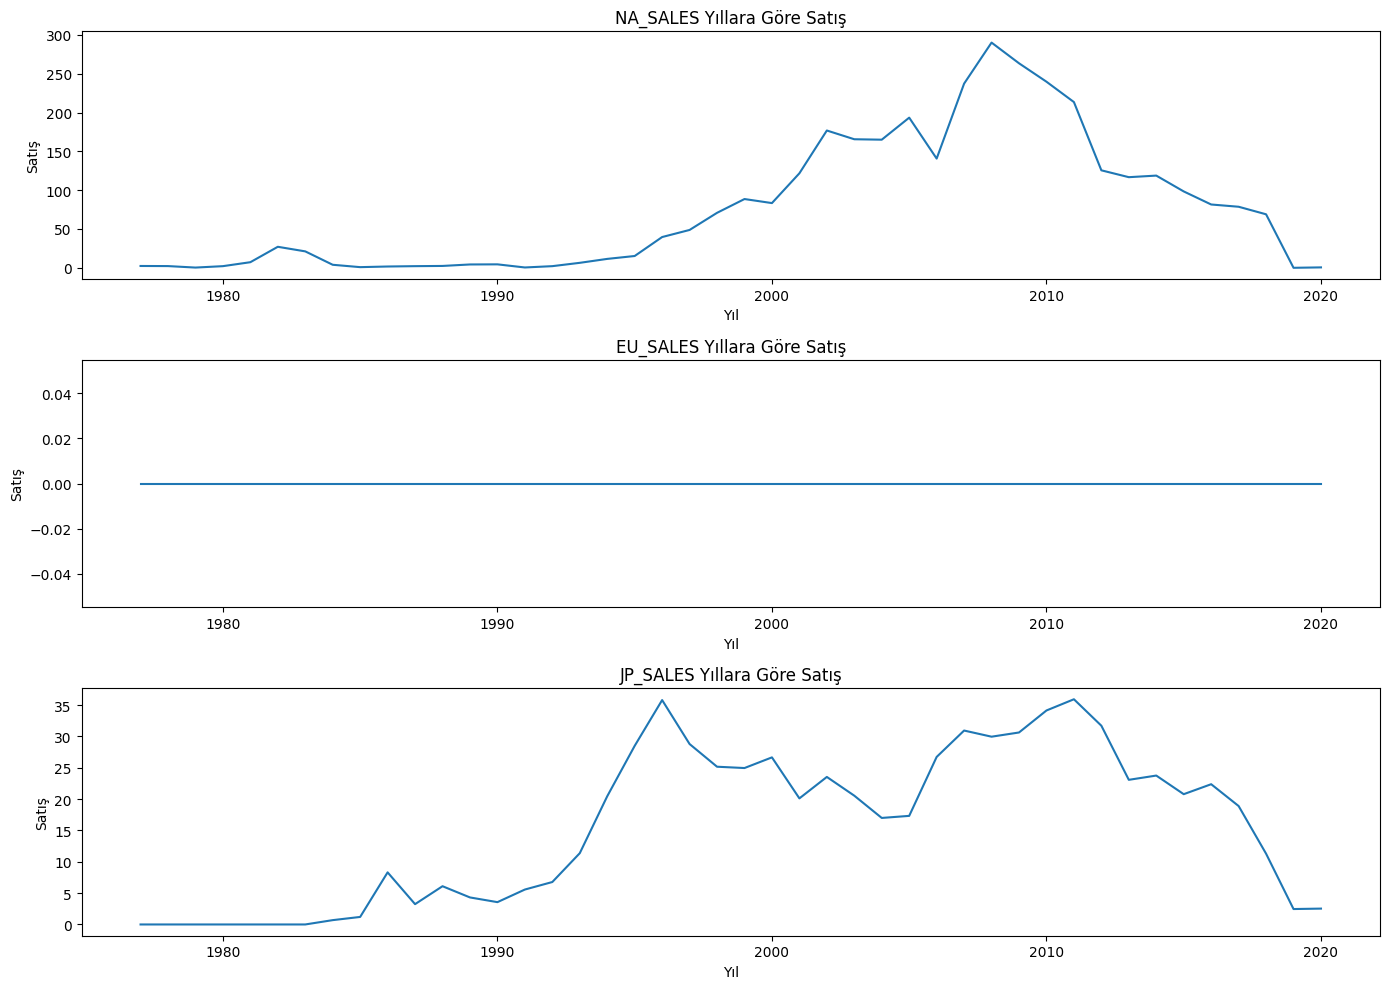

In [81]:
regions = ['na_sales', 'eu_sales', 'jp_sales']

plt.figure(figsize=(14,10))

for i, region in enumerate(regions, 1):
    plt.subplot(3,1,i)
    final_df.groupby('year')[region].sum().plot()
    plt.title(f"{region.upper()} Yıllara Göre Satış")
    plt.xlabel("Yıl")
    plt.ylabel("Satış")

plt.tight_layout()
plt.show()